In [6]:

import numpy as np
import astropy.units as u
from datetime import datetime
today = int(datetime.today().strftime('%Y%m%d'))
from importlib import reload
from astropy.io import fits
import copy
import time
from datetime import timezone 
import tomlkit

import ray

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize, CenteredNorm
from matplotlib.patches import Circle, Rectangle
from matplotlib.gridspec import GridSpec

import esc_llowfsc_sim
import esc_llowfsc_sim.esc_fraunhofer as esc

from lina.math_module import xp, xcipy, ensure_np_array
from lina import iefc, dm, utils, rt_utils, coro_utils

from magpyx.utils import ImageStream

model_path = esc_llowfsc_sim.path/'data/2k-256/'
# model_path = esc_llowfsc_sim.path/'data/1k-256/'
# model_path = esc_llowfsc_sim.path/'data/large/1k-512/' 
with open(model_path/'model_params.toml', mode="r",) as fp:
    params = tomlkit.load(fp).unwrap()
model_params = params['model']

M = esc.single(**model_params)

/home/kianmilani/Projects/poppy/poppy/geometry.py:207: UserWarning: filled_circle_aa may not yield exact results for grey pixels when pixel scale <1
  warnings.warn('filled_circle_aa may not yield exact results for grey pixels when pixel scale <1')


In [25]:
CAMSCI_STREAM = ImageStream('camsci')
CAMSCI_SHUTTER_STREAM = ImageStream('camscishutter')
CAMSCI_EXPTIME_STREAM = ImageStream('camsciexptime')
CAMSCI_GAIN_STREAM = ImageStream('camscigain')
VMAG_STREAM = ImageStream('vmag')
DM_STREAM = ImageStream('dm08disp02')
FSM_STREAM = ImageStream('dm05disp01')

rt_utils.write(VMAG_STREAM, [0])


In [20]:
rt_utils.write(FSM_STREAM, [0e-9, 0e-9, 0])

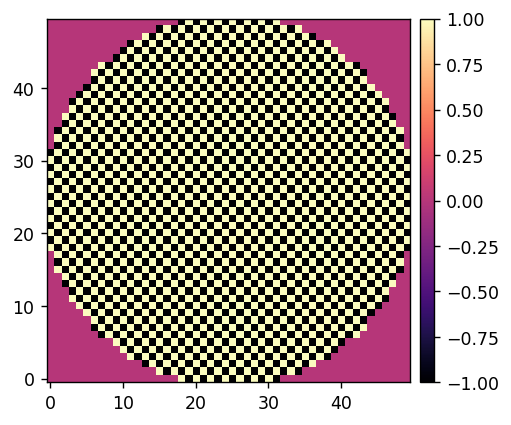

In [17]:
waffle_command = dm.make_fourier_command(x_cpa=25, y_cpa=25, Nact=50) * M.dm_mask
utils.imshow(
    [waffle_command]
)

In [19]:
DM_STREAM.write(ensure_np_array(waffle_command)*50e-9)

In [21]:
DM_STREAM = ImageStream('dm08disp00')

In [24]:
DM_STREAM.write(np.zeros((M.Nact,M.Nact)))